### Step 1: Mount the Google Drive

Remember to use GPU runtime before mounting your Google Drive. (Runtime --> Change runtime type).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Step 2: Open the project directory

Replace `Your_Dir` with your own path.

In [2]:
cd /content/drive/MyDrive/UCLA/ECE247A/emg2qwerty-main

/content/drive/MyDrive/UCLA/ECE247A/emg2qwerty-main


### Step 3: Install required packages

After installing them, Colab will require you to restart the session.

In [5]:
!pip install -r requirements.txt

     - 553.6 kB 579.3 kB/s 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 6.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versions of typer to determine which version is compatible with other requirements. This coul

### Step 4: Start your experiments!

- Remember to download and copy the dataset to this directory: `Your_Dir/emg2qwerty/data`.
- You may now start your experiments with any scripts! Below are examples of single-user training and testing (greedy decoding).
- **There are two ways to track the logs:**
  - 1. Keep `--multirun`, and the logs will not be printed here, but they will be saved in the folder `logs`, e.g., `logs/2025-02-09/18-24-15/submitit_logs/`.
  - 2. Comment out `--multirun` and the logs will be printed in this notebook, but they will not be saved.

#### Training

- The checkpoints are saved in the folder `logs`, e.g., `logs/2025-02-09/18-24-15/checkpoints/`.

In [18]:
# Single-user training
!python -m emg2qwerty.train \
  user="single_user" \
  trainer.accelerator=gpu trainer.devices=1 \
  trainer.max_epochs=40
  # --multirun

[2026-03-13 21:34:56,700][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

#### Testing:

- Replace `Your_Path_to_Checkpoint` with your checkpoint path.

In [4]:
# Single-user testing
!python -m emg2qwerty.train \
  user="single_user" \
  checkpoint="/content/drive/MyDrive/UCLA/ECE247A/emg2qwerty-main/logs/2026-03-08/05-53-16/checkpoints/baseline_best.ckpt" \
  train=False trainer.accelerator=gpu \
  decoder=ctc_greedy \
  hydra.launcher.mem_gb=64 \
  # --multirun

[2026-03-13 23:24:52,602][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

**CNN+LSTM**

2-layer BiLSTM

In [14]:
# 40 epochs
!python -m emg2qwerty.train \
  user="single_user" \
  model=cnn_lstm_ctc \
  trainer.accelerator=gpu trainer.devices=1 \
  trainer.max_epochs=40 \
  num_workers=1

[2026-03-13 18:43:12,768][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

In [7]:
# 150 epochs
!python -m emg2qwerty.train \
  user="single_user" \
  model=cnn_lstm_ctc \
  trainer.accelerator=gpu trainer.devices=1 \
  trainer.max_epochs=150 \
  num_workers=1

[2026-03-13 03:25:31,955][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

Test

In [3]:
!python -m emg2qwerty.train \
  user=single_user \
  model=cnn_lstm_ctc \
  module.lstm_num_layers=2 \
  checkpoint="/content/drive/MyDrive/UCLA/ECE247A/emg2qwerty-main/logs/2026-03-13/18-43-12/checkpoints/2layers_BiLSTM.ckpt" \
  train=false \
  trainer.accelerator=gpu \
  trainer.devices=1 \
  num_workers=1

[2026-03-13 23:22:35,144][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

1 layer BiLSTM

In [ ]:
#40 epochs
!python -m emg2qwerty.train \
  user="single_user" \
  model=cnn_lstm_ctc \
  module.lstm_num_layers=1 \
  trainer.accelerator=gpu trainer.devices=1 \
  trainer.max_epochs=40 \
  num_workers=1

**Figures**

Loss of CNN+LSTM over 40 epochs, from epoch=0

columns: ['lr-Adam', 'step', 'train/loss', 'epoch', 'val/loss', 'val/CER', 'val/IER', 'val/DER', 'val/SER', 'train/CER', 'train/IER', 'train/DER', 'train/SER', 'test/loss', 'test/CER', 'test/IER', 'test/DER', 'test/SER']
        lr-Adam  step  train/loss  epoch    val/loss     val/CER   val/IER  \
0  1.000000e-08     0         NaN    NaN         NaN         NaN       NaN   
1           NaN    49  113.863907    0.0         NaN         NaN       NaN   
2           NaN    99  120.261856    0.0         NaN         NaN       NaN   
3           NaN   119         NaN    0.0  113.107849  640.695618  0.022153   
4           NaN   119         NaN    0.0         NaN         NaN       NaN   

      val/DER    val/SER    train/CER  train/IER   train/DER  train/SER  \
0         NaN        NaN          NaN        NaN         NaN        NaN   
1         NaN        NaN          NaN        NaN         NaN        NaN   
2         NaN        NaN          NaN        NaN         NaN        NaN   
3  553.788

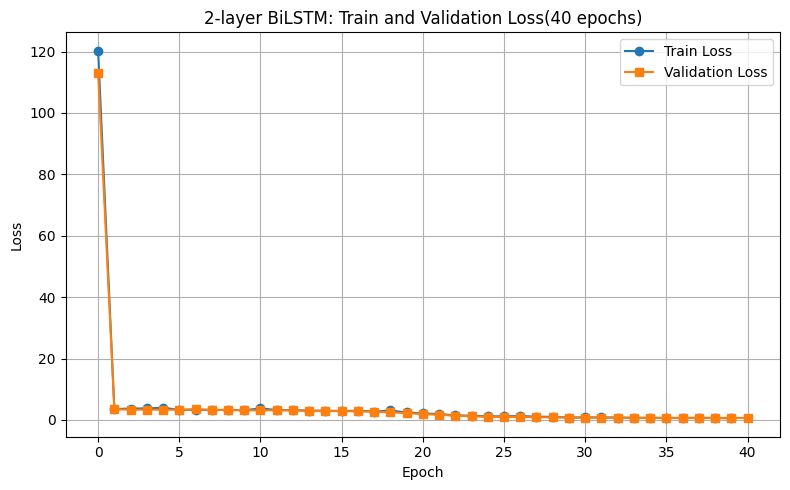

Figure saved to: /content/drive/MyDrive/UCLA/ECE247A/emg2qwerty-main/logs/2026-03-13/18-43-12/csv_logs/version_0/loss_curve_train_val.png


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
metrics_path = Path("/content/drive/MyDrive/UCLA/ECE247A/emg2qwerty-main/logs/2026-03-13/18-43-12/csv_logs/version_0/metrics.csv")

df = pd.read_csv(metrics_path)
print("columns:", df.columns.tolist())
print(df.head())

train_col = None
val_col = None

for c in df.columns:
    c_lower = c.lower()
    if train_col is None and ("train" in c_lower and "loss" in c_lower):
        train_col = c
    if val_col is None and ("val" in c_lower and "loss" in c_lower):
        val_col = c

for preferred in ["train/loss_epoch", "loss_epoch", "train_loss_epoch"]:
    if preferred in df.columns:
        train_col = preferred
        break

for preferred in ["val/loss", "val_loss"]:
    if preferred in df.columns:
        val_col = preferred
        break

print("train loss column:", train_col)
print("val loss column:", val_col)


train_df = df[["epoch", train_col]].dropna().copy()
train_epoch = train_df.groupby("epoch", as_index=False)[train_col].last()

val_df = df[["epoch", val_col]].dropna().copy()
val_epoch = val_df.groupby("epoch", as_index=False)[val_col].last()

print("\nTrain epoch-loss:")
print(train_epoch.head(10))
print("\nVal epoch-loss:")
print(val_epoch.head(10))

plt.figure(figsize=(8, 5))
plt.plot(train_epoch["epoch"], train_epoch[train_col], marker="o", label="Train Loss")
plt.plot(val_epoch["epoch"], val_epoch[val_col], marker="s", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("2-layer BiLSTM: Train and Validation Loss(40 epochs)")
plt.legend()
plt.grid(True)
plt.tight_layout()

save_dir = metrics_path.parent
save_path = save_dir / "loss_curve_train_val.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {save_path}")

Loss of CNN+LSTM over 40 epochs, from epoch=2

train loss column: train/loss
val loss column: val/loss


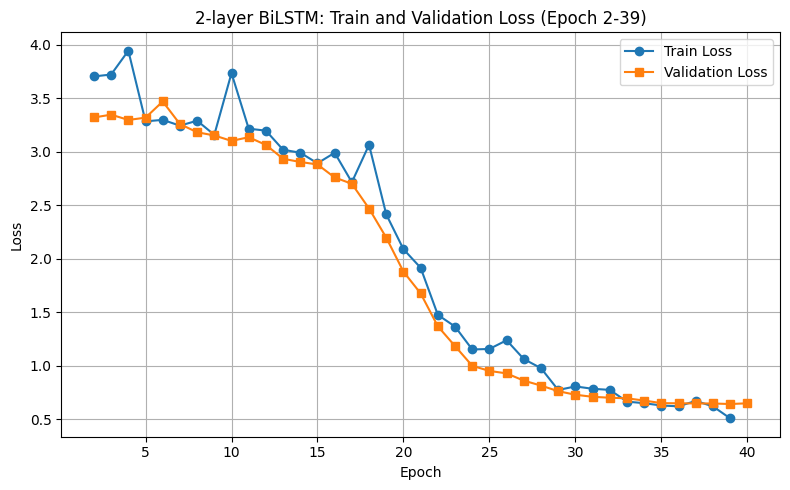

Figure saved to: /content/drive/MyDrive/UCLA/ECE247A/emg2qwerty-main/logs/2026-03-13/18-43-12/csv_logs/version_0/loss_curve_from_epoch2.png


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

metrics_path = Path("/content/drive/MyDrive/UCLA/ECE247A/emg2qwerty-main/logs/2026-03-13/18-43-12/csv_logs/version_0/metrics.csv")

df = pd.read_csv(metrics_path)

train_col = None
val_col = None

for c in df.columns:
    c_lower = c.lower()
    if train_col is None and ("train" in c_lower and "loss" in c_lower):
        train_col = c
    if val_col is None and ("val" in c_lower and "loss" in c_lower):
        val_col = c

for preferred in ["train/loss_epoch", "loss_epoch", "train_loss_epoch"]:
    if preferred in df.columns:
        train_col = preferred
        break

for preferred in ["val/loss", "val_loss"]:
    if preferred in df.columns:
        val_col = preferred
        break

print("train loss column:", train_col)
print("val loss column:", val_col)


train_df = df[["epoch", train_col]].dropna().copy()
train_epoch = train_df.groupby("epoch", as_index=False)[train_col].last()

val_df = df[["epoch", val_col]].dropna().copy()
val_epoch = val_df.groupby("epoch", as_index=False)[val_col].last()


train_epoch = train_epoch[train_epoch["epoch"] >= 2]
val_epoch = val_epoch[val_epoch["epoch"] >= 2]

plt.figure(figsize=(8, 5))
plt.plot(train_epoch["epoch"], train_epoch[train_col], marker="o", label="Train Loss")
plt.plot(val_epoch["epoch"], val_epoch[val_col], marker="s", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("2-layer BiLSTM: Train and Validation Loss (Epoch 2-39)")
plt.legend()
plt.grid(True)
plt.tight_layout()

save_path = metrics_path.parent / "loss_curve_from_epoch2.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {save_path}")

CER of CNN+LSTM over 40 epochs, from epoch=0

train CER column: train/CER
val CER column: val/CER


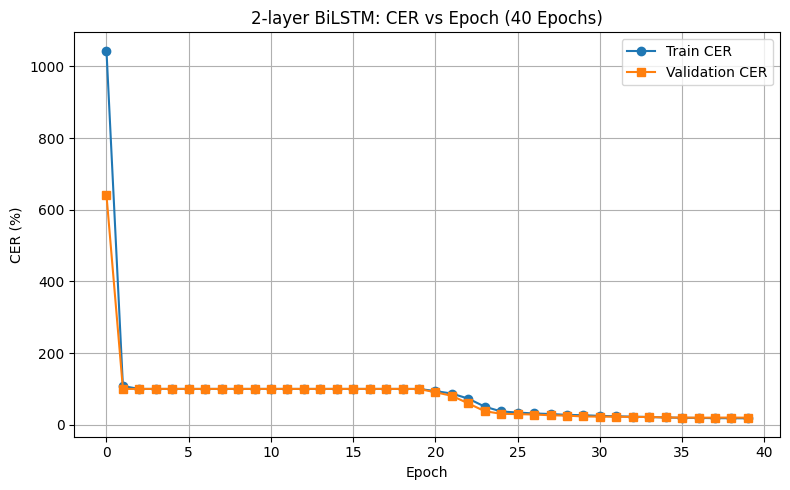

Figure saved to: /content/drive/MyDrive/UCLA/ECE247A/emg2qwerty-main/logs/2026-03-13/18-43-12/csv_logs/version_0/cer_curve_40epochs.png


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

metrics_path = Path("/content/drive/MyDrive/UCLA/ECE247A/emg2qwerty-main/logs/2026-03-13/18-43-12/csv_logs/version_0/metrics.csv")

df = pd.read_csv(metrics_path)

train_cer_col = None
val_cer_col = None

for c in df.columns:
    c_lower = c.lower()
    if train_cer_col is None and ("train" in c_lower and "cer" in c_lower):
        train_cer_col = c
    if val_cer_col is None and ("val" in c_lower and "cer" in c_lower):
        val_cer_col = c

for preferred in ["val/CER", "val_cer", "CER"]:
    if preferred in df.columns:
        val_cer_col = preferred
        break

print("train CER column:", train_cer_col)
print("val CER column:", val_cer_col)

val_cer_df = df[["epoch", val_cer_col]].dropna().copy()
val_cer_epoch = val_cer_df.groupby("epoch", as_index=False)[val_cer_col].last()

if train_cer_col is not None:
    train_cer_df = df[["epoch", train_cer_col]].dropna().copy()
    train_cer_epoch = train_cer_df.groupby("epoch", as_index=False)[train_cer_col].last()
else:
    train_cer_epoch = None

val_cer_epoch = val_cer_epoch[val_cer_epoch["epoch"] <= 39]
if train_cer_epoch is not None:
    train_cer_epoch = train_cer_epoch[train_cer_epoch["epoch"] <= 39]

plt.figure(figsize=(8, 5))

if train_cer_epoch is not None:
    plt.plot(
        train_cer_epoch["epoch"],
        train_cer_epoch[train_cer_col],
        marker="o",
        label="Train CER"
    )

plt.plot(
    val_cer_epoch["epoch"],
    val_cer_epoch[val_cer_col],
    marker="s",
    label="Validation CER"
)

plt.xlabel("Epoch")
plt.ylabel("CER (%)")
plt.title("2-layer BiLSTM: CER vs Epoch (40 Epochs)")
plt.legend()
plt.grid(True)
plt.tight_layout()

save_path = metrics_path.parent / "cer_curve_40epochs.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {save_path}")

CER of CNN+LSTM over 40 epochs, from epoch=2

train CER column: train/CER
val CER column: val/CER


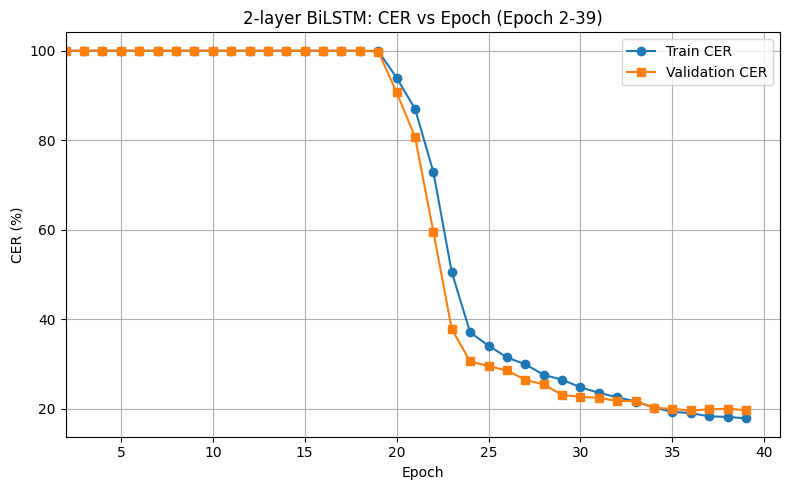

Figure saved to: /content/drive/MyDrive/UCLA/ECE247A/emg2qwerty-main/logs/2026-03-13/18-43-12/csv_logs/version_0/cer_curve_epoch2_39.png


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

metrics_path = Path("/content/drive/MyDrive/UCLA/ECE247A/emg2qwerty-main/logs/2026-03-13/18-43-12/csv_logs/version_0/metrics.csv")

df = pd.read_csv(metrics_path)

train_cer_col = None
val_cer_col = None

for c in df.columns:
    c_lower = c.lower()
    if train_cer_col is None and ("train" in c_lower and "cer" in c_lower):
        train_cer_col = c
    if val_cer_col is None and ("val" in c_lower and "cer" in c_lower):
        val_cer_col = c

for preferred in ["val/CER", "val_cer", "CER"]:
    if preferred in df.columns:
        val_cer_col = preferred
        break

print("train CER column:", train_cer_col)
print("val CER column:", val_cer_col)

val_cer_df = df[["epoch", val_cer_col]].dropna().copy()
val_cer_epoch = val_cer_df.groupby("epoch", as_index=False)[val_cer_col].last()

if train_cer_col is not None:
    train_cer_df = df[["epoch", train_cer_col]].dropna().copy()
    train_cer_epoch = train_cer_df.groupby("epoch", as_index=False)[train_cer_col].last()
else:
    train_cer_epoch = None

val_cer_epoch = val_cer_epoch[(val_cer_epoch["epoch"] >= 2) & (val_cer_epoch["epoch"] <= 39)]

if train_cer_epoch is not None:
    train_cer_epoch = train_cer_epoch[(train_cer_epoch["epoch"] >= 2) & (train_cer_epoch["epoch"] <= 39)]

plt.figure(figsize=(8, 5))

if train_cer_epoch is not None:
    plt.plot(
        train_cer_epoch["epoch"],
        train_cer_epoch[train_cer_col],
        marker="o",
        label="Train CER"
    )

plt.plot(
    val_cer_epoch["epoch"],
    val_cer_epoch[val_cer_col],
    marker="s",
    label="Validation CER"
)

plt.xlabel("Epoch")
plt.ylabel("CER (%)")
plt.title("2-layer BiLSTM: CER vs Epoch (Epoch 2-39)")
plt.xlim(left=2)
plt.legend()
plt.grid(True)
plt.tight_layout()

save_path = metrics_path.parent / "cer_curve_epoch2_39.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {save_path}")

Loss of CNN+LSTM over 150 epochs, from epoch=0

train loss column: train/loss
val loss column: val/loss


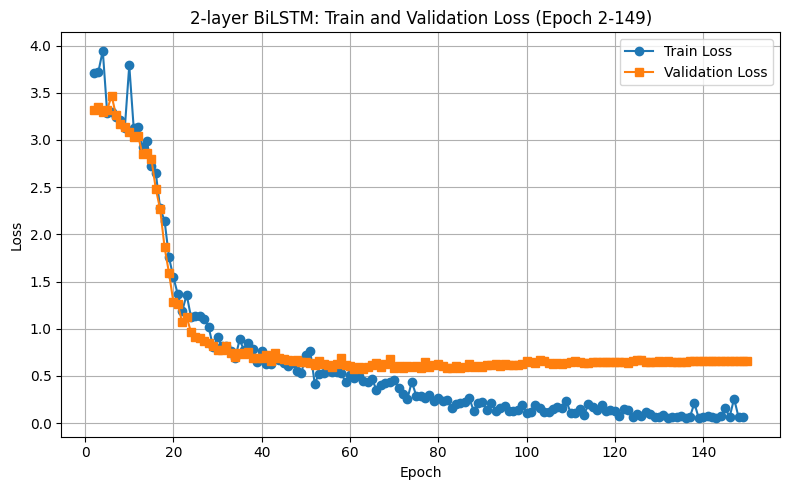

Figure saved to: /content/drive/MyDrive/UCLA/ECE247A/emg2qwerty-main/logs/2026-03-13/03-25-31/csv_logs/version_0/loss_curve_from_epoch2.png


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

metrics_path = Path("/content/drive/MyDrive/UCLA/ECE247A/emg2qwerty-main/logs/2026-03-13/03-25-31/csv_logs/version_0/metrics.csv")

df = pd.read_csv(metrics_path)

train_col = None
val_col = None

for c in df.columns:
    c_lower = c.lower()
    if train_col is None and ("train" in c_lower and "loss" in c_lower):
        train_col = c
    if val_col is None and ("val" in c_lower and "loss" in c_lower):
        val_col = c

for preferred in ["train/loss_epoch", "loss_epoch", "train_loss_epoch"]:
    if preferred in df.columns:
        train_col = preferred
        break

for preferred in ["val/loss", "val_loss"]:
    if preferred in df.columns:
        val_col = preferred
        break

print("train loss column:", train_col)
print("val loss column:", val_col)


train_df = df[["epoch", train_col]].dropna().copy()
train_epoch = train_df.groupby("epoch", as_index=False)[train_col].last()

val_df = df[["epoch", val_col]].dropna().copy()
val_epoch = val_df.groupby("epoch", as_index=False)[val_col].last()


train_epoch = train_epoch[train_epoch["epoch"] >= 2]
val_epoch = val_epoch[val_epoch["epoch"] >= 2]

plt.figure(figsize=(8, 5))
plt.plot(train_epoch["epoch"], train_epoch[train_col], marker="o", label="Train Loss")
plt.plot(val_epoch["epoch"], val_epoch[val_col], marker="s", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("2-layer BiLSTM: Train and Validation Loss (Epoch 2-149)")
plt.legend()
plt.grid(True)
plt.tight_layout()

save_path = metrics_path.parent / "loss_curve_from_epoch2.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {save_path}")

CER of CNN+LSTM over 150 epochs, from epoch=0

train CER column: train/CER
val CER column: val/CER


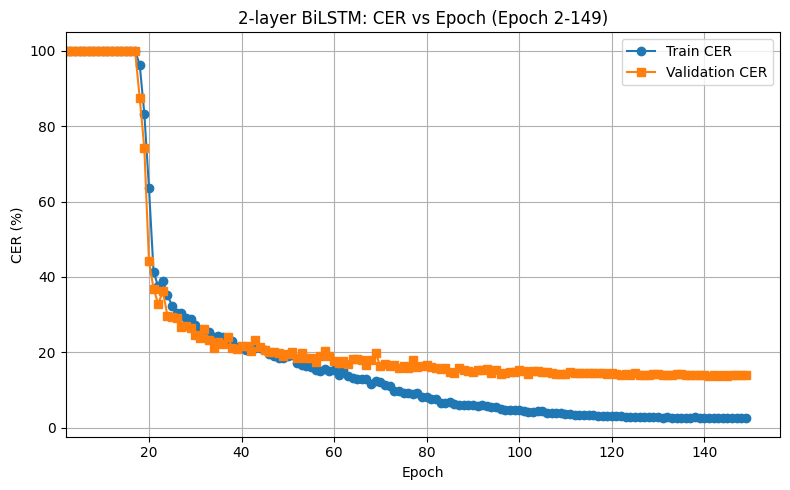

Figure saved to: /content/drive/MyDrive/UCLA/ECE247A/emg2qwerty-main/logs/2026-03-13/03-25-31/csv_logs/version_0/cer_curve_epoch2_39.png


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

metrics_path = Path("/content/drive/MyDrive/UCLA/ECE247A/emg2qwerty-main/logs/2026-03-13/03-25-31/csv_logs/version_0/metrics.csv")

df = pd.read_csv(metrics_path)

train_cer_col = None
val_cer_col = None

for c in df.columns:
    c_lower = c.lower()
    if train_cer_col is None and ("train" in c_lower and "cer" in c_lower):
        train_cer_col = c
    if val_cer_col is None and ("val" in c_lower and "cer" in c_lower):
        val_cer_col = c

for preferred in ["val/CER", "val_cer", "CER"]:
    if preferred in df.columns:
        val_cer_col = preferred
        break

print("train CER column:", train_cer_col)
print("val CER column:", val_cer_col)

val_cer_df = df[["epoch", val_cer_col]].dropna().copy()
val_cer_epoch = val_cer_df.groupby("epoch", as_index=False)[val_cer_col].last()

if train_cer_col is not None:
    train_cer_df = df[["epoch", train_cer_col]].dropna().copy()
    train_cer_epoch = train_cer_df.groupby("epoch", as_index=False)[train_cer_col].last()
else:
    train_cer_epoch = None

val_cer_epoch = val_cer_epoch[(val_cer_epoch["epoch"] >= 2) & (val_cer_epoch["epoch"] <= 149)]

if train_cer_epoch is not None:
    train_cer_epoch = train_cer_epoch[(train_cer_epoch["epoch"] >= 2) & (train_cer_epoch["epoch"] <= 149)]

plt.figure(figsize=(8, 5))

if train_cer_epoch is not None:
    plt.plot(
        train_cer_epoch["epoch"],
        train_cer_epoch[train_cer_col],
        marker="o",
        label="Train CER"
    )

plt.plot(
    val_cer_epoch["epoch"],
    val_cer_epoch[val_cer_col],
    marker="s",
    label="Validation CER"
)

plt.xlabel("Epoch")
plt.ylabel("CER (%)")
plt.title("2-layer BiLSTM: CER vs Epoch (Epoch 2-149)")
plt.xlim(left=2)
plt.legend()
plt.grid(True)
plt.tight_layout()

save_path = metrics_path.parent / "cer_curve_epoch2_39.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {save_path}")